# Inference — Student Risk Prediction

This notebook loads the trained model and applies it to new data using the optimized decision threshold.

In [17]:
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Load Model 

In [11]:
BASE_DIR = Path.cwd().parent
MODEL_PATH = BASE_DIR / "models" / "modelo_risco.pkl"

artifact = joblib.load(MODEL_PATH)

model = artifact["model"]
features = artifact["features"]


In [12]:
def create_sample(ian_2022, ian_2023):
    delta = ian_2023 - ian_2022
    ratio = ian_2023 / (ian_2022 + 1e-6)

    data = {
        "ian_2022": ian_2022,
        "ian_2023": ian_2023,
        "delta_ian": delta,
        "ratio_ian": ratio
    }

    df = pd.DataFrame([data])

    df = df.reindex(columns=features, fill_value=0)

    return df

## Scenarios

In [13]:
scenarios = {
    "Stable": create_sample(7, 7),
    "Moderate decline": create_sample(7, 4),
    "Strong decline": create_sample(8, 3),
}


## Predictions

In [14]:
results = []

for name, sample in scenarios.items():
    proba = model.predict_proba(sample)[0][1]
    score = int(proba * 100)

    if proba < 0.2:
        level = "Low"
    elif proba < 0.5:
        level = "Medium"
    else:
        level = "High"

    results.append({
        "Scenario": name,
        "Risk Score": score,
        "Risk Level": level
    })

df_results = pd.DataFrame(results)


In [15]:
print(df_results)

           Scenario  Risk Score Risk Level
0            Stable           7        Low
1  Moderate decline          47     Medium
2    Strong decline          89       High


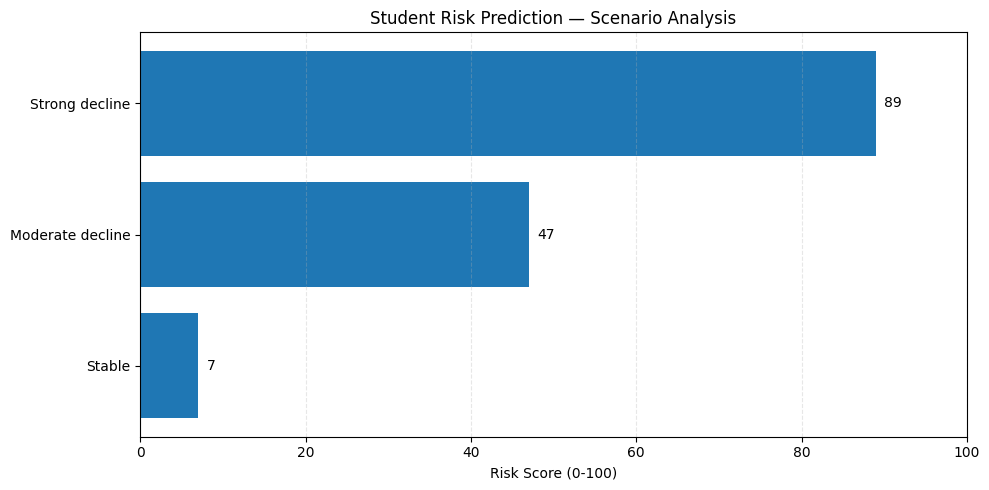

In [18]:

df_plot = df_results.sort_values("Risk Score")

plt.figure(figsize=(10, 5))
bars = plt.barh(df_plot["Scenario"], df_plot["Risk Score"])

for i, v in enumerate(df_plot["Risk Score"]):
    plt.text(v + 1, i, f"{v}", va='center')

plt.xlabel("Risk Score (0-100)")
plt.title("Student Risk Prediction — Scenario Analysis")
plt.xlim(0, 100)
plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig("grafico_modelo.png", bbox_inches="tight")
plt.show()